In [45]:
import os
os.makedirs("outputs", exist_ok=True)
# Cell 1 — Imports + load data + fix date columns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

DATA = r"C:\Users\akki7\OneDrive\Desktop\ecommerce-funnel\data"

orders   = pd.read_csv(f"{DATA}/olist_orders_dataset.csv")
payments = pd.read_csv(f"{DATA}/olist_order_payments_dataset.csv")
items    = pd.read_csv(f"{DATA}/olist_order_items_dataset.csv")

# Convert text → real datetime columns
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print("✓ Data loaded. Date columns converted.")
print(orders[date_cols].dtypes)

✓ Data loaded. Date columns converted.
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [34]:
# Cell 2 — How long did each order take to deliver?
orders["delivery_days"] = (
    orders["order_delivered_customer_date"] -
    orders["order_purchase_timestamp"]
).dt.days

avg_delivery = orders["delivery_days"].mean()
med_delivery = orders["delivery_days"].median()

print(f"Average delivery time: {avg_delivery:.1f} days")
print(f"Median delivery time:  {med_delivery:.1f} days")
print(f"Fastest delivery:      {orders['delivery_days'].min()} days")
print(f"Slowest delivery:      {orders['delivery_days'].max()} days")

Average delivery time: 12.1 days
Median delivery time:  10.0 days
Fastest delivery:      0.0 days
Slowest delivery:      209.0 days


In [35]:
# Cell 3 — Join orders with payments

# First: collapse payments to one row per order
# (remember: some orders have multiple payment rows)
payment_summary = payments.groupby("order_id").agg(
    total_payment = ("payment_value", "sum"),
    payment_type  = ("payment_type",  "first")
).reset_index()

# Now merge: combine orders + payment_summary on order_id
df = orders.merge(payment_summary, on="order_id", how="left")

print(f"orders rows:          {len(orders):,}")
print(f"payment_summary rows: {len(payment_summary):,}")
print(f"merged df rows:       {len(df):,}")
print(f"\nNew columns: {list(df.columns[-4:])}")

orders rows:          99,441
payment_summary rows: 99,440
merged df rows:       99,441

New columns: ['order_estimated_delivery_date', 'delivery_days', 'total_payment', 'payment_type']


In [36]:
# Cell 4 — How much revenue per order status?
revenue_by_status = df.groupby("order_status").agg(
    order_count   = ("order_id",      "count"),
    total_revenue = ("total_payment", "sum"),
    avg_revenue   = ("total_payment", "mean")
).reset_index()

revenue_by_status["total_revenue"] = revenue_by_status["total_revenue"].round(2)
revenue_by_status["avg_revenue"]   = revenue_by_status["avg_revenue"].round(2)

revenue_by_status = revenue_by_status.sort_values("order_count", ascending=False)
print(revenue_by_status.to_string(index=False))

order_status  order_count  total_revenue  avg_revenue
   delivered        96478    15422461.77       159.86
     shipped         1107      177213.96       160.08
    canceled          625      143255.60       229.21
 unavailable          609      126479.51       207.68
    invoiced          314       69137.99       220.18
  processing          301       69394.11       230.55
     created            5         688.10       137.62
    approved            2         241.08       120.54


In [37]:
df[df["order_status"]=="canceled"]["delivery_days"].describe()

count     6.000000
mean     19.833333
std      13.136463
min       7.000000
25%       7.750000
50%      20.000000
75%      30.000000
max      35.000000
Name: delivery_days, dtype: float64

In [38]:
df.groupby("order_status")["delivery_days"].mean().round(1)

order_status
approved        NaN
canceled       19.8
created         NaN
delivered      12.1
invoiced        NaN
processing      NaN
shipped         NaN
unavailable     NaN
Name: delivery_days, dtype: float64

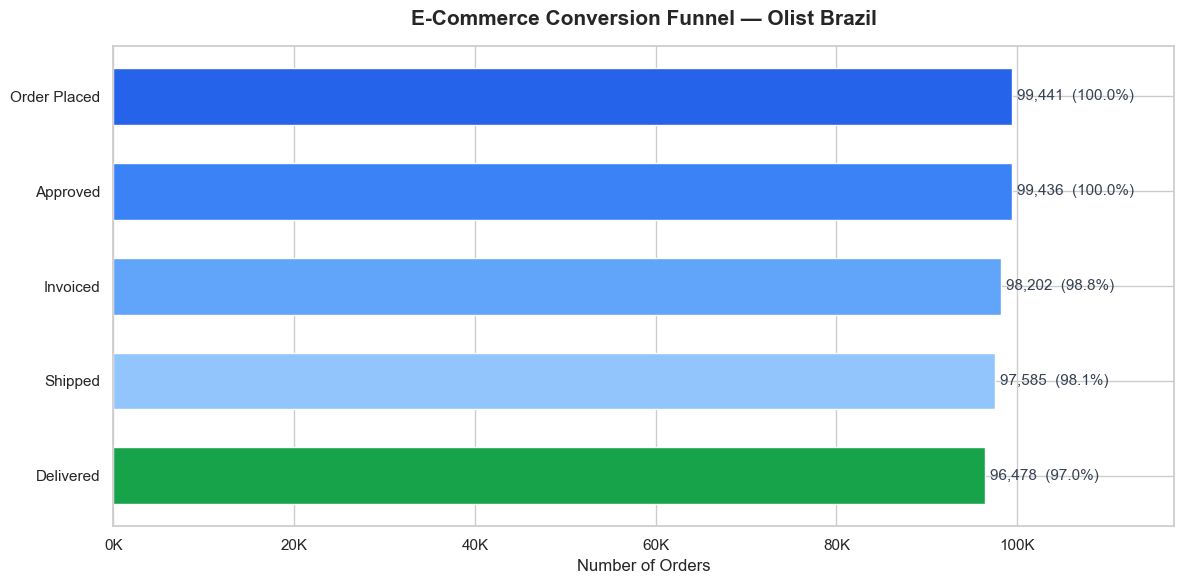

✓ Funnel chart saved


In [49]:
# Cell 5 — Conversion funnel chart

# Define funnel stages in order
funnel_stages = [
    ("Order Placed",    len(df)),
    ("Approved",        (df["order_status"] != "created").sum()),
    ("Invoiced",        df["order_status"].isin([
                            "invoiced","processing","shipped",
                            "delivered","approved"]).sum()),
    ("Shipped",         df["order_status"].isin([
                            "shipped","delivered"]).sum()),
    ("Delivered",      (df["order_status"] == "delivered").sum()),
]

stages  = [s[0] for s in funnel_stages]
counts  = [s[1] for s in funnel_stages]
total   = counts[0]
pcts    = [c / total * 100 for c in counts]

# Draw horizontal funnel
fig, ax = plt.subplots(figsize=(12, 6))
colors  = ["#2563eb","#3b82f6","#60a5fa","#93c5fd","#16a34a"]

bars = ax.barh(stages, counts, color=colors, edgecolor="white", height=0.6)

# Add labels on each bar
for i, (bar, count, pct) in enumerate(zip(bars, counts, pcts)):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f"{count:,}  ({pct:.1f}%)",
            va="center", fontsize=11, color="#374151")

ax.set_xlabel("Number of Orders", fontsize=12)
ax.set_title("E-Commerce Conversion Funnel — Olist Brazil",
             fontsize=15, fontweight="bold", pad=15)
ax.invert_yaxis()
ax.set_xlim(0, total * 1.18)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
plt.tight_layout()
plt.savefig("outputs/03_conversion_funnel.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Funnel chart saved")

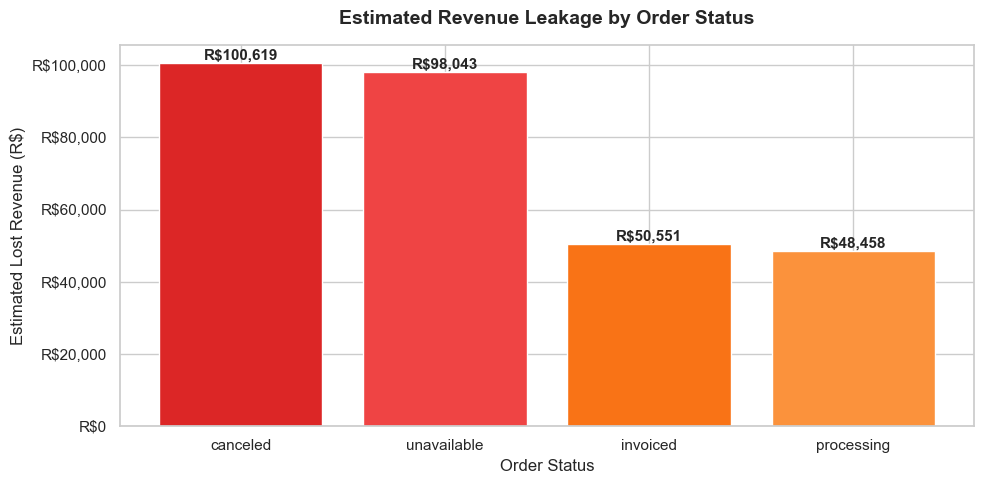


💸 Total estimated revenue leakage: R$297,671


In [47]:
# Cell 6 — Revenue leakage: how much money was lost per status?
avg_val = df["total_payment"].mean()

leakage_statuses = ["canceled", "unavailable", "processing", "invoiced"]
leakage = revenue_by_status[
    revenue_by_status["order_status"].isin(leakage_statuses)
].copy()

leakage["est_lost_revenue"] = leakage["order_count"] * avg_val

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(leakage["order_status"], leakage["est_lost_revenue"],
              color=["#dc2626","#ef4444","#f97316","#fb923c"],
              edgecolor="white")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f"R${bar.get_height():,.0f}",
            ha="center", fontsize=11, fontweight="bold")

ax.set_title("Estimated Revenue Leakage by Order Status",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Order Status")
ax.set_ylabel("Estimated Lost Revenue (R$)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"R${x:,.0f}"))
plt.tight_layout()
plt.savefig("outputs/04_revenue_leakage.png", dpi=150, bbox_inches="tight")
plt.show()

total_leakage = leakage["est_lost_revenue"].sum()
print(f"\n💸 Total estimated revenue leakage: R${total_leakage:,.0f}")

In [41]:
total_leakage = leakage["est_lost_revenue"].sum()
total_leakage

np.float64(297671.00311625097)

In [42]:
df[df["order_status"]=="canceled"]["delivery_days"].describe()

count     6.000000
mean     19.833333
std      13.136463
min       7.000000
25%       7.750000
50%      20.000000
75%      30.000000
max      35.000000
Name: delivery_days, dtype: float64

In [43]:
df.groupby("order_status")["delivery_days"].mean().round(1)

order_status
approved        NaN
canceled       19.8
created         NaN
delivered      12.1
invoiced        NaN
processing      NaN
shipped         NaN
unavailable     NaN
Name: delivery_days, dtype: float64

In [44]:
# What % of cancelled orders were approved before cancellation?
cancelled = df[df["order_status"] == "canceled"]

approved_then_cancelled = cancelled["order_approved_at"].notna().sum()
total_cancelled = len(cancelled)

print(f"Total cancelled orders:              {total_cancelled}")
print(f"Had payment approved before cancel:  {approved_then_cancelled}")
print(f"Cancelled before approval:           {total_cancelled - approved_then_cancelled}")
print(f"% approved before cancel:            {approved_then_cancelled/total_cancelled*100:.1f}%")

Total cancelled orders:              625
Had payment approved before cancel:  484
Cancelled before approval:           141
% approved before cancel:            77.4%
